In [1]:
# requires gseapy:
# pip install gseapy

In [3]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import gseapy as gp

In [4]:
# GO and KEGG pathway enrichment analysis using gseapy
project_dir = Path.cwd().parent
deg_matrix = pd.read_csv(project_dir / "quants" / "GSE60450_deseq2_results.csv", index_col=0)

# Filter gene list for GO/KEGG analysisbased on adjusted p-value and log2 fold change
deg_significant_matrix_up = deg_matrix[(deg_matrix["padj"] < 0.05) & (deg_matrix["log2FoldChange"] > 1)].copy()
gene_list_up = deg_significant_matrix_up["gene_name"].dropna().astype(str).drop_duplicates().tolist()
deg_significant_matrix_down = deg_matrix[(deg_matrix["padj"] < 0.05) & (deg_matrix["log2FoldChange"] < -1)].copy()
gene_list_down = deg_significant_matrix_down["gene_name"].dropna().astype(str).drop_duplicates().tolist()


In [ ]:
# GO and KEGG enrichment analysis using gseapy
# Create output directory for GO results
go_output_dir = project_dir / "quants" / "GSE60450_GO"
go_output_dir.mkdir(parents=True, exist_ok=True)

# Perform GO enrichment analysis for upregulated genes
go_enrichment_up = gp.enrichr(
    gene_list=gene_list_up,
    gene_sets="GO_Biological_Process_2021",   # for human use "GO_Biological_Process_2021"
    organism="mouse",
    outdir=str(project_dir / "quants" / "GSE60450_GO"),
    cutoff=0.05
)
go_up_df = go_enrichment_up.results.copy()
go_up_df.to_csv(project_dir / "quants" / "GSE60450_GO" / "GSE60450_GO_enrichment_up_results.csv", index=False)

# Perform GO enrichment analysis for downregulated genes
go_enrichment_down = gp.enrichr(
    gene_list=gene_list_down,
    gene_sets="GO_Biological_Process_2021",   # for human use "GO_Biological_Process_2021"
    organism="mouse",
    outdir=str(project_dir / "quants" / "GSE60450_GO"),
    cutoff=0.05
)
go_down_df = go_enrichment_down.results.copy()
go_down_df.to_csv(project_dir / "quants" / "GSE60450_GO" / "GSE60450_GO_enrichment_down_results.csv", index=False)

# Create output directory for KEGG results
kegg_output_dir = project_dir / "quants" / "GSE60450_KEGG"
kegg_output_dir.mkdir(parents=True, exist_ok=True)

# Explore libraries available for KEGG in gseapy for mouse
libs = gp.get_library_name(organism="mouse")
[k for k in libs if "KEGG" in k]

# Perform KEGG pathway enrichment analysis for upregulated genes
kegg_enrichment_up = gp.enrichr(
    gene_list=gene_list_up,
    gene_sets="KEGG_2019_Mouse",
    organism="mouse",
    outdir=str(project_dir / "quants" / "GSE60450_KEGG"), 
    cutoff=0.05
)
kegg_up_df = kegg_enrichment_up.results.copy()
kegg_up_df.to_csv(project_dir / "quants" / "GSE60450_KEGG" / "GSE60450_KEGG_enrichment_up_results.csv", index=False)

# Perform KEGG pathway enrichment analysis for downregulated genes
kegg_enrichment_down = gp.enrichr(
    gene_list=gene_list_down,
    gene_sets="KEGG_2019_Mouse",
    organism="mouse",
    outdir=str(project_dir / "quants" / "GSE60450_KEGG"), 
    cutoff=0.05
)
kegg_down_df = kegg_enrichment_down.results.copy()
kegg_down_df.to_csv(project_dir / "quants" / "GSE60450_KEGG" / "GSE60450_KEGG_enrichment_down_results.csv", index=False)


In [ ]:
# Plot enrichment results with matplotlib / seaborn (the function could be used for KEGG results as well)
sns.set_theme(style="whitegrid", context="talk")

def prepare_enrichment_plot_df(results_df, top_n=10):
    if results_df.empty:
        return pd.DataFrame()

    plot_df = results_df.copy()
    plot_df["Adjusted P-value"] = pd.to_numeric(plot_df["Adjusted P-value"], errors="coerce")
    plot_df["Combined Score"] = pd.to_numeric(plot_df.get("Combined Score"), errors="coerce")

    if "Overlap" in plot_df.columns:
        plot_df["Gene Count"] = plot_df["Overlap"].str.split("/").str[0].astype(float)
    else:
        plot_df["Gene Count"] = np.nan

    plot_df = plot_df.dropna(subset=["Term", "Adjusted P-value"])
    plot_df = plot_df[plot_df["Adjusted P-value"] > 0].copy()
    plot_df = plot_df.sort_values(["Adjusted P-value", "Combined Score"], ascending=[True, False]).head(top_n).copy()
    plot_df["-log10(adj p-value)"] = -np.log10(plot_df["Adjusted P-value"])
    plot_df["Term"] = plot_df["Term"].str.replace(r" \(GO:\d+\)$", "", regex=True)

    return plot_df.sort_values("-log10(adj p-value)", ascending=False)

def plot_enrichment_barplot(label, results_df, title, color, output_path, top_n=10):
    plot_df = prepare_enrichment_plot_df(results_df, top_n=top_n)

    if plot_df.empty:
        if label == "GO":
            print(f"No {label} terms passed filtering for {title}.")
        return

    fig_height = max(4, 0.6 * len(plot_df) + 1.5)
    fig, ax = plt.subplots(figsize=(12, fig_height))
    sns.barplot(data=plot_df, x="-log10(adj p-value)", y="Term", color=color, ax=ax)

    ax.set_title(title, pad=12, weight="bold")
    ax.set_xlabel("-log10 adjusted p-value")
    ax.set_ylabel(f"{label} Biological Process")
    ax.spines[["top", "right"]].set_visible(False)

    # Add gene count labels if available
    if plot_df["Gene Count"].notna().any():
        x_offset = plot_df["-log10(adj p-value)"].max() * 0.02
        for patch, gene_count in zip(ax.patches, plot_df["Gene Count"]):
            if pd.notna(gene_count):
                ax.text(
                    patch.get_width() + x_offset,
                    patch.get_y() + patch.get_height() / 2,
                    f"n={int(gene_count)}",
                    va="center",
                    fontsize=10,
                )

    plt.tight_layout()
    fig.savefig(output_path, dpi=300, bbox_inches="tight")
    plt.show()

# barplot for GO enrichment results
plot_enrichment_barplot(
    label="GO",
    results_df=go_up_df,
    title="Top GO Biological Processes: Upregulated Genes",
    color="#D55E00",
    output_path=go_output_dir / "GSE60450_GO_up_barplot.png",
)

plot_enrichment_barplot(
    label="GO",
    results_df=go_down_df,
    title="Top GO Biological Processes: Downregulated Genes",
    color="#0072B2",
    output_path=go_output_dir / "GSE60450_GO_down_barplot.png",
)

# barplot for KEGG enrichment results
plot_enrichment_barplot(
    label="KEGG",
    results_df=kegg_up_df,
    title="Top KEGG Pathways: Upregulated Genes",
    color="#D55E00",
    output_path=kegg_output_dir / "GSE60450_KEGG_up_barplot.png",
)

plot_enrichment_barplot(
    label="KEGG",
    results_df=kegg_down_df,
    title="Top KEGG Pathways: Downregulated Genes",
    color="#0072B2",
    output_path=kegg_output_dir / "GSE60450_KEGG_down_barplot.png",
)


In [5]:
# GSEA analysis using gseapy's prerank function
# Prepare output directory for GSEA results
gsea_output_dir = project_dir / "quants" / "GSE60450_GSEA"
gsea_output_dir.mkdir(parents=True, exist_ok=True)

# Prepare a preranked table for GSEA using the DESeq2 Wald statistic.
# gp.prerank expects a two-column DataFrame/Series, such as:
#  1) gene identifier; 2) ranking metric (here we use "stat" from DESeq2 results. other common choice: -log10(padj) * log2FoldChange)
ranked_gene_df = deg_matrix[["gene_name", "stat"]].copy()

ranked_gene_df["gene_name"] = ranked_gene_df["gene_name"].astype(str).str.strip()
ranked_gene_df["stat"] = pd.to_numeric(ranked_gene_df["stat"], errors="coerce")

ranked_gene_df = ranked_gene_df.replace([np.inf, -np.inf], np.nan)
ranked_gene_df = ranked_gene_df.dropna(subset=["gene_name", "stat"])
ranked_gene_df = ranked_gene_df[~ranked_gene_df["gene_name"].str.lower().isin(["", "nan", "none"])]

ranked_gene_df = ranked_gene_df.sort_values("stat", ascending=False)
ranked_gene_df = ranked_gene_df.drop_duplicates(subset="gene_name", keep="first")

# gene_sets can be:
# - an Enrichr library name (e.g. "KEGG_2019_Mouse")
# - a GMT file path
# - a Python dict of gene sets
gene_sets_libs = "KEGG_2019_Mouse";

# Perform GSEA analysis using prerank
gsea_results = gp.prerank(
    rnk=ranked_gene_df,
    gene_sets=gene_sets_libs,
    permutation_num=1000,
    min_size=15,
    max_size=500,
    outdir=str(gsea_output_dir),
    seed=42,
    verbose=True,
)

# gseapy stores the tabular summary in .res2d
gsea_df = gsea_results.res2d.copy()
gsea_df.to_csv(gsea_output_dir / "GSE60450_GSEA_enrichment_results.csv", index=False)
gsea_df.head()


2026-04-21 12:13:29,230 [WARNING] Duplicated values found in preranked stats: 6.70% of genes
The order of those genes will be arbitrary, which may produce unexpected results.
2026-04-21 12:13:29,231 [INFO] Parsing data files for GSEA.............................
2026-04-21 12:13:29,253 [INFO] Enrichr library gene sets already downloaded in: /home/r/.cache/gseapy, use local file
2026-04-21 12:13:29,268 [INFO] 0015 gene_sets have been filtered out when max_size=500 and min_size=15
2026-04-21 12:13:29,269 [INFO] 0288 gene_sets used for further statistical testing.....
2026-04-21 12:13:29,270 [INFO] Start to run GSEA...Might take a while..................
2026-04-21 12:13:29,272 [INFO] Genes are converted to uppercase.
2026-04-21 12:13:50,222 [INFO] Congratulations. GSEApy runs successfully................



,Name,Term,ES,NES,NOM p-val,FDR q-val,FWER p-val,Tag %,Gene %,Lead_genes
0,prerank,Ribosome,0.656066,2.684815,0.0,0.0,0.0,94/138,23.41%,Rps26;Mrps12;Rplp1;Mrps18a;Mrpl11;Mrpl14;Mrpl3...
1,prerank,Oxidative phosphorylation,0.653255,2.597347,0.0,0.0,0.0,92/116,26.63%,Atp6v0e2;Atp6v1d;Atp6v1b1;Atp6v1h;Atp6v1b2;Atp...
2,prerank,Proteasome,0.694942,2.380154,0.0,0.0,0.0,33/44,21.93%,Psmb8;Psmb1;Psmd8;Psmb9;Psmd3;Pomp;Psmc5;Psme3...
3,prerank,Focal adhesion,-0.609624,-2.33168,0.0,0.0,0.0,98/196,17.45%,Mylk;Myl9;Reln;Itga1;Col4a2;Itga9;Lama1;Ccnd2;...
4,prerank,Collecting duct acid secretion,0.782572,2.31333,0.0,0.0,0.0,11/26,5.72%,Atp6v0e2;Car2;Atp6v1d;Atp6v1b1;Atp6v1b2;Atp6v1...


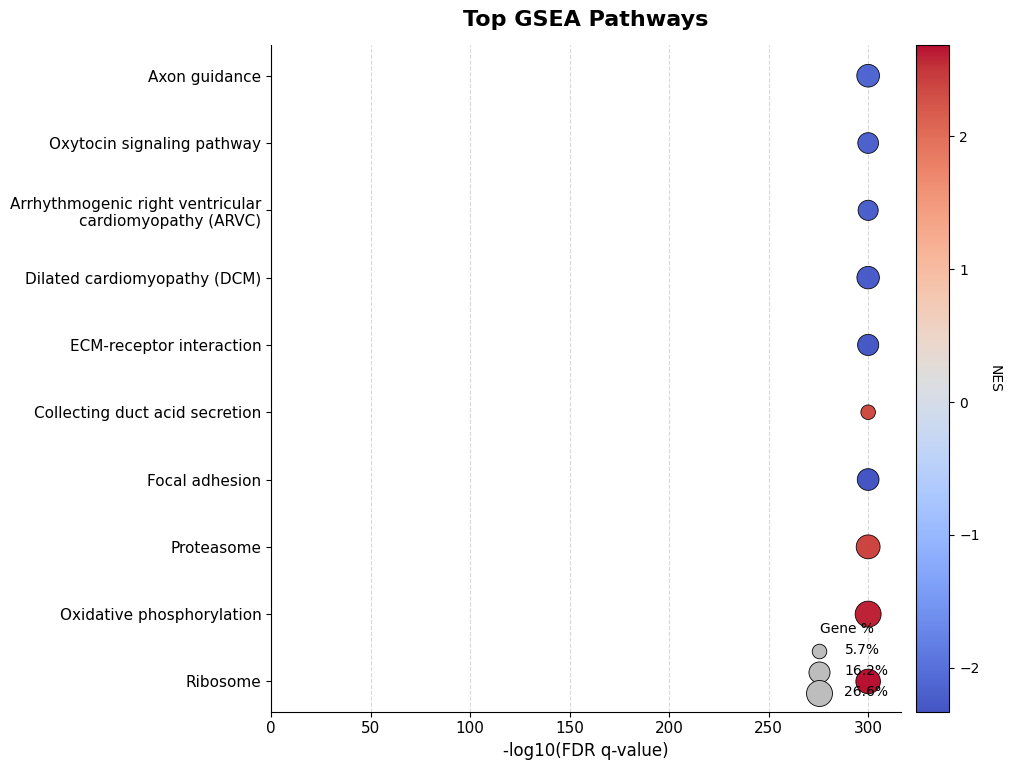

In [ ]:
# prepare GSEA results for plotting
# return gsea_up_df (pd.DataFrame, top positively enriched pathways) and gsea_down_df (pd.DataFrame, top negatively enriched pathways)
def prepare_gsea_plot_dfs(gsea_df, top_n=10):
    plot_df = gsea_df.copy()

    # convert key statistical columns to numeric
    plot_df["NES"] = pd.to_numeric(plot_df["NES"], errors="coerce")
    plot_df["FDR q-val"] = pd.to_numeric(plot_df["FDR q-val"], errors="coerce")

    # remove rows missing essential info
    plot_df = plot_df.dropna(subset=["Term", "NES", "FDR q-val"])
    plot_df = plot_df[plot_df["FDR q-val"] >= 0].copy()
    
    # Avoid -inf when FDR is 0
    plot_df["-log10(FDR)"] = -np.log10(plot_df["FDR q-val"].clip(lower=1e-300))

    # convert Gene % like "12.5%" to numeric values for bubble size mapping
    if "Gene %" in plot_df.columns:
        plot_df["Gene % value"] = (
            plot_df["Gene %"]
            .astype(str)
            .str.rstrip("%")
            .replace("", np.nan)
            .astype(float)
        )
    else:
        plot_df["Gene % value"] = np.nan

    # Perserve original term and make plotting label shorter
    plot_df["Term_clean"] = plot_df["Term"].astype(str)
    plot_df["Term"] = plot_df["Term"].str.wrap(38)

    # Split by direction
    gsea_up_df = plot_df[plot_df["NES"] > 0].copy()
    gsea_down_df = plot_df[plot_df["NES"] < 0].copy()

    # Rank within each direction
    # Up: smaller FDR first, then larger NES; Down: smaller FDR first, then more negative NES first
    gsea_up_df = gsea_up_df.sort_values(
        ["FDR q-val", "NES"], ascending=[True, False]
    ).head(top_n).copy()
    gsea_down_df = gsea_down_df.sort_values(
        ["FDR q-val", "NES"], ascending=[True, True]
    ).head(top_n).copy()

    # Return in display order for plotting
    gsea_up_df = gsea_up_df.sort_values("-log10(FDR)", ascending=True, wrap_width=38)
    gsea_down_df = gsea_down_df.sort_values("-log10(FDR)", ascending=True)

    return gsea_up_df, gsea_down_df

# summary dot plot for the top enriched pathways
gsea_up_df, gsea_down_df = prepare_gsea_plot_dfs(gsea_df, top_n=10)

if gsea_up_df.empty and gsea_down_df.empty:
    print("No GSEA terms available for plotting.")
else:
    fig_height = max(5, 0.6 * len(gsea_plot_df) + 1.8)
    fig, ax = plt.subplots(figsize=(10.5, fig_height))

    size_values = gsea_plot_df["Gene % value"].copy()
    if size_values.notna().any():
        min_size = size_values.min()
        max_size = size_values.max()
        if max_size > min_size:
            bubble_sizes = 110 + ((size_values - min_size) / (max_size - min_size)) * 240
        else:
            bubble_sizes = pd.Series(200, index=gsea_plot_df.index)
    else:
        bubble_sizes = gsea_plot_df["-log10(FDR)"] * 55 + 80

    scatter = ax.scatter(
        gsea_plot_df["-log10(FDR)"],
        gsea_plot_df["Term"],
        s=bubble_sizes,
        c=gsea_plot_df["NES"],
        cmap="coolwarm",
        edgecolor="black",
        linewidth=0.6,
        alpha=0.95,
    )

    ax.grid(axis="x", color="#D9D9D9", linestyle="--", linewidth=0.8)
    ax.grid(axis="y", visible=False)
    ax.set_axisbelow(True)
    ax.set_title("Top GSEA Pathways", pad=14, weight="bold", fontsize=16)
    ax.set_xlabel("-log10(FDR q-value)", fontsize=12)
    ax.set_ylabel("")
    ax.spines[["top", "right"]].set_visible(False)
    ax.tick_params(axis="y", labelsize=11)
    ax.tick_params(axis="x", labelsize=11)
    ax.set_xlim(left=0)

    cbar = plt.colorbar(scatter, ax=ax, pad=0.02)
    cbar.set_label("NES", rotation=270, labelpad=16)

    if size_values.notna().any():
        size_reference = np.linspace(size_values.min(), size_values.max(), 3)
        size_reference = np.unique(np.round(size_reference, 1))
        bubble_reference = []
        for value in size_reference:
            if max_size > min_size:
                marker_size = 110 + ((value - min_size) / (max_size - min_size)) * 240
            else:
                marker_size = 200
            bubble_reference.append(
                plt.scatter([], [], s=marker_size, facecolor="#BDBDBD", edgecolor="black", linewidth=0.6, label=f"{value:g}%")
            )
        ax.legend(
            handles=bubble_reference,
            title="Gene %",
            frameon=False,
            loc="lower right",
        )

    plt.tight_layout()
    fig.savefig(gsea_output_dir / "GSE60450_GSEA_summary_dotplot.png", dpi=300, bbox_inches="tight")
    plt.show()


# enrichment curves for the top 5 pathways
top_gsea_terms = prepare_gsea_plot_df(gsea_df, top_n=5).sort_values(["FDR q-val", "abs_NES"], ascending=[True, False])

for _, row in top_gsea_terms.iterrows():
    term = row["Term"]
    term_result = gsea_results.results[term]
    safe_term = "".join(ch if ch.isalnum() or ch in ("-", "_") else "_" for ch in term).strip("_")

    gp.gseaplot(
        rank_metric=gsea_results.ranking,
        term=term,
        ofname=str(gsea_output_dir / f"GSE60450_GSEA_{safe_term}_curve.png"),
        **term_result,
    )

    plt.show()
